# Tuning Exploration Parameters

## 📚 Learning Objectives

By completing this notebook, you will:
- Tune exploration parameters (epsilon, temperature, etc.)
- Understand parameter impact on performance
- Find optimal exploration settings
- Apply parameter tuning strategies

## 🔗 Prerequisites

- ✅ Understanding of exploration strategies
- ✅ Understanding of hyperparameter tuning
- ✅ Python, NumPy, Matplotlib knowledge

---

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 4**:
- Tuning exploration parameters

---

## Introduction

Tuning exploration parameters is crucial for balancing exploration and exploitation effectivel

## Lesson Brief

This lesson shows that exploration is not only about choosing a strategy, but also about tuning its parameters well.

Students will see how choices such as epsilon size or decay schedule affect learning outcomes.

Why this matters: an algorithm can fail not because the idea is wrong, but because its exploration settings are poor.

This lesson builds practical instinct for parameter tuning.

## Recommended YouTube Video

To reinforce this lesson, watch **ritvikmath - "Best Multi-Armed Bandit Strategy? (feat: UCB Method)"**:
[Watch on YouTube](https://www.youtube.com/watch?v=FgmMK6RPU1c)

Why this pick:
- Clear English accent and concrete parameter-sensitive examples.
- Helps students see how exploration settings change learning behavior over time.
- Good companion when interpreting tuning experiments rather than only running them.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Exploration: trying uncertain actions.
- Exploitation: using the current best action.
- Epsilon: explore probability.
- Regret: loss from not always choosing the best action.

### Quick Check
- Why is pure exploitation risky early?
- What changes when epsilon is high or low?
- How do the plots reveal the trade-off?

### Common Mistakes
- Assuming exploration means permanent randomness.
- Using one lucky run as proof.
- Confusing exploration rate with learning rate.


## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

import numpy as np
import matplotlib.pyplot as plt

print("✅ Libraries imported!")
print("\nTuning Exploration Parameters")
print("=" * 60)

print("\nKey Exploration Parameters:")
print("  - Epsilon (ε): Exploration rate for epsilon-greedy")
print("  - Temperature (τ): For Boltzmann exploration")
print("  - Confidence parameter (c): For UCB")
print("  - Decay rate: For epsilon decay schedules")

print("\nTuning Strategies:")
print("  1. Grid search over parameter ranges")
print("  2. Adaptive schedules (decay over time)")
print("  3. Context-dependent parameters")
print("  4. Performance-based tuning")

print("\n✅ Parameter tuning concepts covered!")

✅ Libraries imported!

Tuning Exploration Parameters

Key Exploration Parameters:
  - Epsilon (ε): Exploration rate for epsilon-greedy
  - Temperature (τ): For Boltzmann exploration
  - Confidence parameter (c): For UCB
  - Decay rate: For epsilon decay schedules

Tuning Strategies:
  1. Grid search over parameter ranges
  2. Adaptive schedules (decay over time)
  3. Context-dependent parameters
  4. Performance-based tuning

✅ Parameter tuning concepts covered!


## 🌍 Worked Example — Tuning Epsilon in A/B Testing

**Industry context:**
- Product teams often keep the bandit setup fixed but tune exploration strength
- A weak epsilon can lock onto a bad option too early
- A very high epsilon can waste traffic on poor variants for too long

We run the same A/B test with several **epsilon values** so students can see how parameter tuning changes performance even when the strategy stays the same.

### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


Total rewards by epsilon:
  ε=0.01: total reward=595, final avg CTR=0.297
  ε=0.05: total reward=416, final avg CTR=0.208
  ε= 0.1: total reward=643, final avg CTR=0.322
  ε= 0.3: total reward=644, final avg CTR=0.322

Best epsilon in this run: ε=0.3
Teaching point: low epsilon may under-explore, while high epsilon may keep wasting traffic on weak arms.


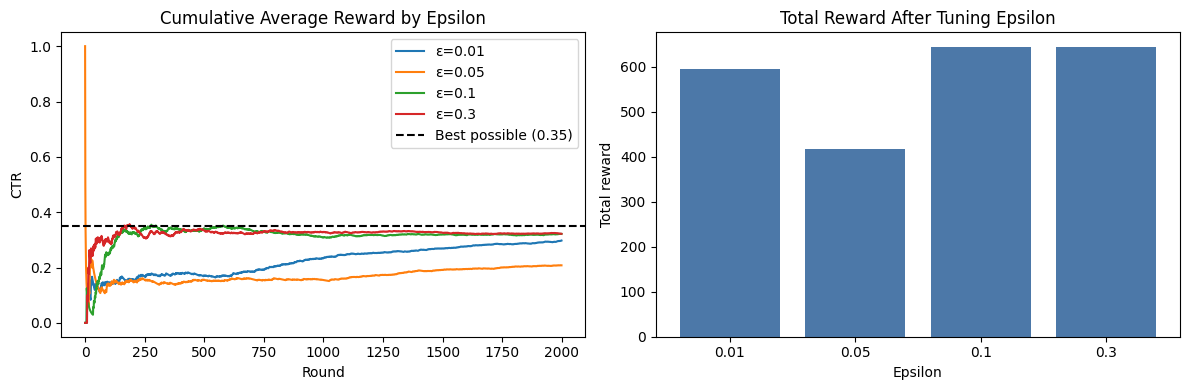

In [2]:
# Worked example: keep the strategy fixed and tune epsilon itself.
# This makes the parameter effect visible without changing the underlying algorithm.

import numpy as np, matplotlib.pyplot as plt

TRUE_RATES = [0.15, 0.22, 0.35, 0.18, 0.28]
N_ARMS = len(TRUE_RATES)
N_ROUNDS = 2000
EPSILONS = [0.01, 0.05, 0.10, 0.30]
BEST_RATE = max(TRUE_RATES)

def run_epsilon_greedy(eps, seed):
    rng = np.random.default_rng(seed)
    counts = np.zeros(N_ARMS)
    totals = np.zeros(N_ARMS)
    rewards = []

    for _ in range(N_ROUNDS):
        if rng.random() < eps:
            arm = rng.integers(N_ARMS)
        else:
            arm = int(np.argmax(totals / (counts + 1e-9)))
        reward = 1 if rng.random() < TRUE_RATES[arm] else 0
        counts[arm] += 1
        totals[arm] += reward
        rewards.append(reward)

    return np.array(rewards)

def cumulative_average(values):
    return np.cumsum(values) / np.arange(1, len(values) + 1)

results = {}
for idx, eps in enumerate(EPSILONS):
    rewards = run_epsilon_greedy(eps, seed=42 + idx)
    results[eps] = {
        "rewards": rewards,
        "total_reward": int(rewards.sum()),
        "final_average": cumulative_average(rewards)[-1],
    }

best_eps = max(results, key=lambda eps: results[eps]["total_reward"])
print("Total rewards by epsilon:")
for eps in EPSILONS:
    print(f"  ε={eps:>4}: total reward={results[eps]['total_reward']}, final avg CTR={results[eps]['final_average']:.3f}")
print(f"\nBest epsilon in this run: ε={best_eps}")
print("Teaching point: low epsilon may under-explore, while high epsilon may keep wasting traffic on weak arms.")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
for eps in EPSILONS:
    plt.plot(cumulative_average(results[eps]["rewards"]), label=f"ε={eps}")
plt.axhline(BEST_RATE, color="k", linestyle="--", label=f"Best possible ({BEST_RATE})")
plt.title("Cumulative Average Reward by Epsilon")
plt.xlabel("Round")
plt.ylabel("CTR")
plt.legend()

plt.subplot(1, 2, 2)
epsilon_labels = [str(eps) for eps in EPSILONS]
totals = [results[eps]["total_reward"] for eps in EPSILONS]
plt.bar(epsilon_labels, totals, color="#4C78A8")
plt.title("Total Reward After Tuning Epsilon")
plt.xlabel("Epsilon")
plt.ylabel("Total reward")
plt.tight_layout()
plt.show()

## 📚 References & Further Reading

**Book:** Sutton & Barto — [RL Introduction Ch.2: Multi-armed Bandits](http://incompleteideas.net/book/the-book-2nd.html)
**Paper:** Auer et al. (2002) — [Finite-time Analysis of UCB](https://link.springer.com/article/10.1023/A:1013689704352)

**Real-World Usage:**
- Google uses Thompson Sampling in Google Ads for A/B testing at scale
- Netflix uses bandit algorithms to pick which thumbnail to show each user

**State-of-the-Art:** ε-greedy and UCB are still dominant in industry A/B testing systems.

## 📝 Summary

You compared **exploration strategies**: ε-greedy (simple, effective), UCB (optimism under uncertainty), and Thompson Sampling (Bayesian). The exploration-exploitation tradeoff is central to RL. Real applications: A/B testing at Netflix, ad bidding at Google, recommendation engines at Spotify.

### Step Guide

**What this cell does:** This cell turns the lesson outputs into a final visual recap.

**Why this matters:** Weak coders often understand charts faster than raw arrays or printed dictionaries.

**What to expect in the output:** Expect one or more plots that summarize the most important numbers from the notebook.

**Common student confusion:** Students should use this as a summary view after understanding the earlier steps, not as a replacement for them.


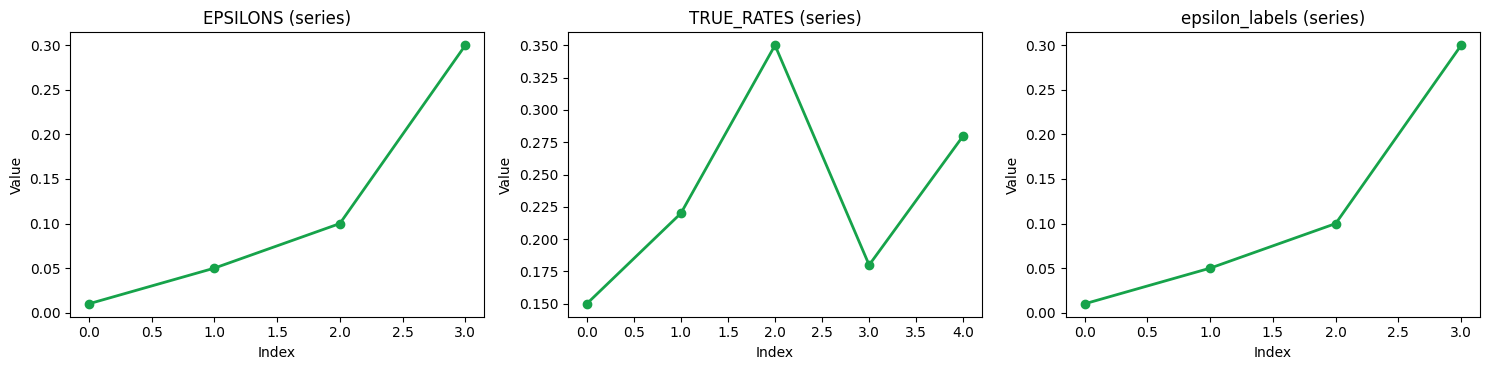

In [3]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
import numbers
import numpy as np
import matplotlib.pyplot as plt

def _is_number(value):
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

def _as_numeric_dict(value):
    if not isinstance(value, dict) or not value or len(value) > 12:
        return None
    converted = []
    for item in value.values():
        if not _is_number(item):
            return None
        converted.append(float(item))
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

def _as_numeric_array(value, dims):
    try:
        array = np.asarray(value, dtype=float)
    except Exception:
        return None
    if array.ndim != dims:
        return None
    if dims == 1 and not (2 <= array.size <= 200):
        return None
    if dims == 2 and array.size > 400:
        return None
    return array

priority_names = [
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
]

skip_names = {"np", "plt", "numbers", "math"}
candidates = []
seen = set()
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

for name in search_space:
    if name in seen or name not in globals() or name in skip_names:
        continue
    seen.add(name)
    value = globals()[name]

    dict_payload = _as_numeric_dict(value)
    if dict_payload is not None:
        candidates.append(("dict", name, dict_payload))
        if len(candidates) == 3:
            break
        continue

    array_2d = _as_numeric_array(value, 2)
    if array_2d is not None:
        candidates.append(("heatmap", name, array_2d))
        if len(candidates) == 3:
            break
        continue

    array_1d = _as_numeric_array(value, 1)
    if array_1d is not None:
        candidates.append(("line", name, array_1d))
        if len(candidates) == 3:
            break

if not candidates:
    summary = {
        "functions": sum(callable(value) for value in globals().values()),
        "classes": sum(isinstance(value, type) for value in globals().values()),
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    }
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    ax.set_title("Notebook artifact summary")
    ax.set_ylabel("Count")
    for idx, value in enumerate(summary.values()):
        ax.text(idx, value + 0.05, str(value), ha="center")
    plt.tight_layout()
    plt.show()
else:
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    if len(candidates) == 1:
        axes = [axes]

    for ax, (kind, name, payload) in zip(axes, candidates):
        if kind == "dict":
            labels, values = payload
            ax.bar(range(len(values)), values, color="#2563eb")
            ax.set_xticks(range(len(values)))
            ax.set_xticklabels(labels, rotation=45, ha="right")
            ax.set_title(f"{name} (dict)")
            ax.set_ylabel("Value")
        elif kind == "line":
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            ax.set_title(f"{name} (series)")
            ax.set_xlabel("Index")
            ax.set_ylabel("Value")
        else:
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            ax.set_title(f"{name} (heatmap)")
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Parameter tuning changes how aggressively or cautiously an agent explores, which can strongly affect speed and final performance.

**If students remember one idea:** A strategy is only half the story. Its parameter values determine how it behaves in the real run.

**Quick check before moving on:**
- Can you explain why a strong method can still perform poorly with weak parameter choices?
- Can you describe which signals you would inspect while tuning exploration?

**Bridge to the next step:** This closes Unit 4 and prepares students to apply RL ideas in larger, more realistic domains.
